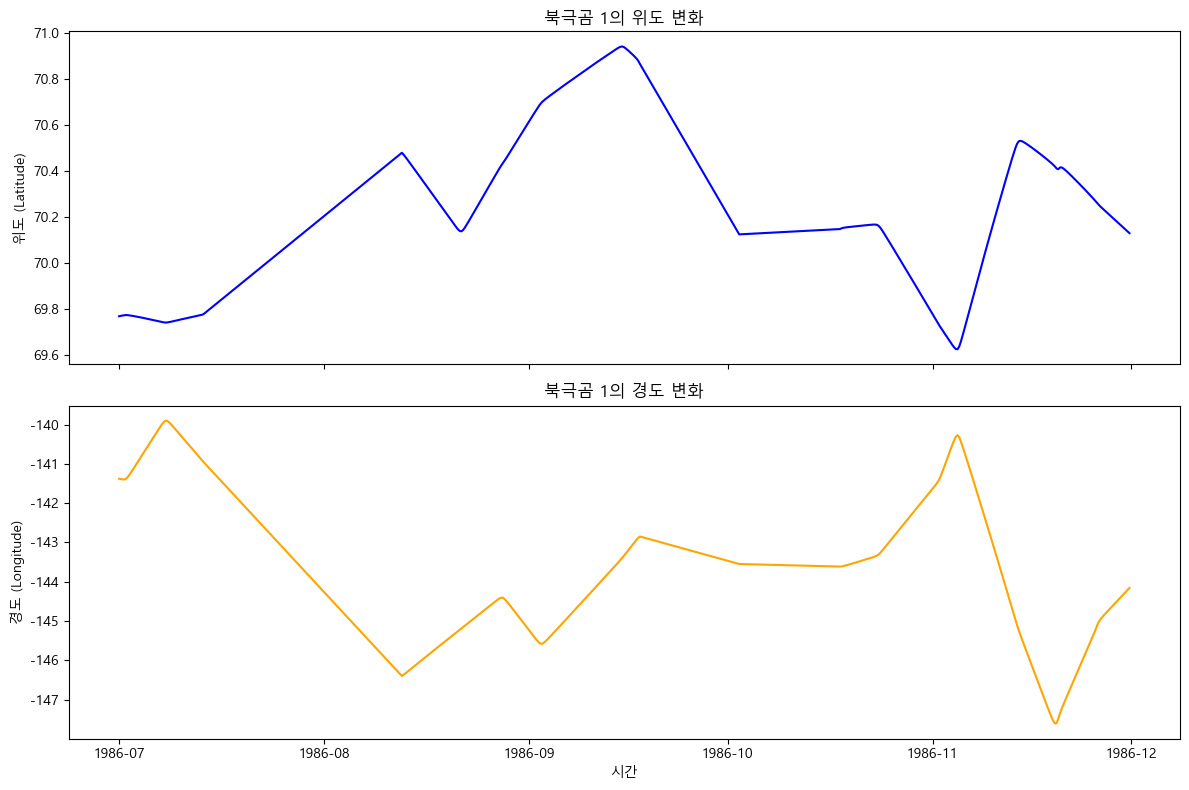

In [12]:
# 📦 라이브러리 임포트
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster

# 📁 데이터 로딩
df = pd.read_csv("보퍼트해 북극곰 위성추적 1985-2017.csv")

# 🕒 시간 데이터 형식 변경
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 🌐 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 🐻 북극곰 한 마리 선택하여 시계열 분석
animal_id = df['UniqueAnimalID'].unique()[0]
bear_df = df[df['UniqueAnimalID'] == animal_id]

# 📈 위도 및 경도 시계열 그래프 (분리)
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(bear_df['timestamp'], bear_df['mu_lat'], color='blue')
axs[0].set_ylabel('위도 (Latitude)')
axs[0].set_title(f"북극곰 {animal_id}의 위도 변화")

axs[1].plot(bear_df['timestamp'], bear_df['mu_lon'], color='orange')
axs[1].set_ylabel('경도 (Longitude)')
axs[1].set_title(f"북극곰 {animal_id}의 경도 변화")

plt.xlabel("시간")
plt.tight_layout()
plt.show()

# 📍 위도 60도 이상 필터링
filtered_df = df[(df['mu_lat'] > 60) & (df['mu_lon'] >= -180) & (df['mu_lon'] <= 180)]
sample_df = filtered_df.sample(500, random_state=42)

# 🗺️ 지도 생성 (중심 좌표 자동 계산)
map_center = [sample_df['mu_lat'].mean(), sample_df['mu_lon'].mean()]
m = folium.Map(location=map_center, zoom_start=4)

# ❄️ 해빙 느낌 지도 스타일 추가
folium.TileLayer(
    tiles='https://tiles.stadiamaps.com/tiles/alidade_smooth_dark/{z}/{x}/{y}{r}.png',
    attr='Stadia Maps',
    name='빙하 느낌 지도',
    overlay=True,
    control=True
).add_to(m)

# 📌 클러스터 마커 추가
marker_cluster = MarkerCluster().add_to(m)

for idx, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row['mu_lat'], row['mu_lon']],
        radius=2,
        popup=f"ID: {row['UniqueAnimalID']}, {row['timestamp']}",
        color='skyblue',
        fill=True,
        fill_opacity=0.6
    ).add_to(marker_cluster)

# 🧭 레이어 컨트롤 추가
folium.LayerControl().add_to(m)

# 📍 지도 표시 (주피터 환경에서)
m


In [4]:
!pip install folium